# Análisis del Desarrollo Educativo y la Finalización Escolar Femenina

## Introducción
El análisis de indicadores educativos es fundamental para comprender cómo evolucionan el acceso, la equidad y la permanencia escolar en distintos países. Diversos organismos internacionales han señalado que la finalización de la educación primaria constituye un punto crítico en el desarrollo humano, pues condiciona oportunidades futuras y refleja desigualdades persistentes (UNESCO, 2021; UNICEF, 2022). Estas brechas afectan especialmente a las niñas en contextos de vulnerabilidad, donde factores económicos y sociales limitan la continuidad escolar (World Bank, 2023).

Para este estudio se utilizan datos del **World Development Indicators (WDI)**, una base estadística global del Banco Mundial que reúne información armonizada, comparable entre países y actualizada anualmente. Su estructura estandarizada permite analizar tendencias de largo plazo y contrastar diferencias regionales con un alto nivel de confiabilidad (World Bank Data Group, 2022).

El indicador central analizado es **Primary completion rate, female (% of relevant age group)** (SE.PRM.CMPT.FE.ZS), que mide el porcentaje de niñas que completan la educación primaria dentro de la edad oficial. Su relevancia radica en que:

- refleja desigualdades de género en el progreso escolar,  
- permite evaluar la capacidad de los sistemas educativos para garantizar trayectorias completas,  
- se vincula a metas internacionales como los Objetivos de Desarrollo Sostenible (UNESCO, 2021),  
- señala barreras estructurales que afectan la permanencia escolar femenina.

El uso de WDI es adecuado para este análisis porque sus datos están armonizados internacionalmente, cuenta con series históricas amplias y es validado por organismos multilaterales, lo que lo convierte en una fuente confiable para estudiar la evolución de la finalización escolar.

---

### Objetivo del análisis 

Antes de profundizar en comparaciones entre países, este estudio realiza un **análisis exploratorio de datos (EDA)** con el fin de comprender, de manera clara y accesible, cómo se comporta cada variable por separado: su distribución, variabilidad, valores extremos y posibles patrones internos. Esta primera mirada permite detectar anomalías, evaluar la calidad de los datos y sentar las bases para interpretaciones más complejas.

Dado que el indicador de finalización primaria posee registros anuales, también incorporamos un **enfoque de serie de tiempo**. Esto significa que no solo observamos la variable en un momento puntual, sino que evaluamos cómo evoluciona a lo largo del tiempo. Para asegurar que esta evaluación sea válida, aplicamos previamente la prueba de **Dickey–Fuller aumentada (ADF)**, que permite identificar si la serie es estacionaria o si presenta tendencias persistentes. El resultado (estadístico ADF = –2.82; p‑value = 0.055) indica que la serie no es plenamente estacionaria, lo que revela una tendencia temporal suave que debe tenerse en cuenta al interpretar los cambios anuales.

Incluir este componente temporal en el EDA enriquece la interpretación del fenómeno educativo y evita conclusiones basadas únicamente en fotos aisladas del tiempo.

---

### Obtención y procesamiento de datos

Los datos utilizados en este análisis fueron extraídos directamente desde la base **World Development Indicators (WDI)** del Banco Mundial mediante una interfaz en Python que permite acceder a la API oficial. Esta herramienta facilita la descarga automatizada de series estadísticas, la selección de indicadores específicos y la definición de rangos temporales de interés, devolviendo los resultados en un formato estructurado adecuado para análisis tipo panel.

El uso de esta interfaz garantiza que los valores obtenidos provengan de la versión más reciente y validada de WDI, evitando errores derivados de descargas manuales o conversiones inconsistentes. Además, permite incorporar metadatos relevantes —como información regional o clasificación de ingreso de los países— cuando estos son necesarios para comparaciones adicionales. De esta manera, el proceso de extracción de datos mantiene criterios de reproducibilidad, estandarización y coherencia metodológica, aspectos fundamentales para asegurar la calidad del análisis estadístico.

In [ ]:
%pip install wbdata 

In [3]:
import wbdata
import datetime

indicadores = {
    "SE.PRM.CMPT.FE.ZS": "female_completion"
}

# Rango de fechas
fecha_inicio = datetime.datetime(2000, 1, 1)
fecha_fin = datetime.datetime(2022, 1, 1)

df = wbdata.get_dataframe(indicadores, date=(fecha_inicio, fecha_fin))

df.head()


female_completion
country                     date                   
Africa Eastern and Southern 2022          70.935730
                            2021          71.491768
                            2020          70.187447
                            2019          69.208900
                            2018          68.506729

Al cargar la data, aparece como si todo fuera una sola columna por lo que procedemos a resetear el indice de la siguiente manera:

In [4]:
df = df.reset_index()
df.columns
df.head()

,country,date,female_completion
0,Africa Eastern and Southern,2022,70.935730
1,Africa Eastern and Southern,2021,71.491768
2,Africa Eastern and Southern,2020,70.187447
3,Africa Eastern and Southern,2019,69.208900
4,Africa Eastern and Southern,2018,68.506729


De esta forma es posible evidenciar ya corregido el dataframe, ahora bien vamos a renombrar las columnas para trabajar con ellas de manera mas facil

In [5]:
df.columns = ["pais", "anio", "tasa_fin"]
df.head()
df.shape

(6118, 3)

In [6]:
df.head(4)

,pais,anio,tasa_fin
0,Africa Eastern and Southern,2022,70.935730
1,Africa Eastern and Southern,2021,71.491768
2,Africa Eastern and Southern,2020,70.187447
3,Africa Eastern and Southern,2019,69.208900


A partir de la informacion de la estructura del dataset es posible observar que hay datos faltantes, pero primero eliminaremos las filas duplicadas si hay

In [7]:

df = df.drop_duplicates()
df.info()

<class 'wbdata.client.DataFrame'>
RangeIndex: 6118 entries, 0 to 6117
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pais      6118 non-null   object 
 1   anio      6118 non-null   object 
 2   tasa_fin  4062 non-null   float64
dtypes: float64(1), object(2)
memory usage: 143.5+ KB


En Dtype es posible identificar que de las 3 variables existentes en el Dataframe, la variable "anio" no es del tipo que le corresponde, las otras 2 si coinciden con su tipo de variable, por lo que haremos el respectivo cambio de variable

In [8]:
df["anio"] = df["anio"].astype("Int64")
df.dtypes

pais         object
anio          Int64
tasa_fin    float64
dtype: object

Vamos a dividir ahora nuestro df en 2, ya que la primera parte muestras agrupaciones regionales y bloques geograficos, y la segunda parte si se logran observar paises individuales y su informacion

In [9]:
df_1 = df.iloc[:1127]
df_2 = df.iloc[1127:]

In [10]:
df_1.info

<bound method DataFrame.info of                              pais  anio   tasa_fin
0     Africa Eastern and Southern  2022  70.935730
1     Africa Eastern and Southern  2021  71.491768
2     Africa Eastern and Southern  2020  70.187447
3     Africa Eastern and Southern  2019  69.208900
4     Africa Eastern and Southern  2018  68.506729
...                           ...   ...        ...
1122                        World  2004  82.195053
1123                        World  2003  81.392647
1124                        World  2002  80.556351
1125                        World  2001  79.945801
1126                        World  2000  78.769112

[1127 rows x 3 columns]>

In [11]:
df_2.info

<bound method DataFrame.info of              pais  anio   tasa_fin
1127  Afghanistan  2022        NaN
1128  Afghanistan  2021        NaN
1129  Afghanistan  2020        NaN
1130  Afghanistan  2019  69.613503
1131  Afghanistan  2018  70.630531
...           ...   ...        ...
6113     Zimbabwe  2004        NaN
6114     Zimbabwe  2003  91.379852
6115     Zimbabwe  2002  92.397690
6116     Zimbabwe  2001  97.191200
6117     Zimbabwe  2000        NaN

[4991 rows x 3 columns]>

Habiendo dividido el df, ahora eliminaremos las filas que tengan por lo menos un valor faltante y de esta manera pasaremos con nuestra EDA

In [12]:
data = df_2.dropna(axis=0)
data.shape

(3004, 3)

In [13]:
import pandas as pd

cols = data.columns

if "pais" in cols:
    country_col = "pais"
else:
    raise ValueError("No encuentro la columna de país")

if "anio" in cols:
    year_col = "anio"
else:
    raise ValueError("No encuentro la columna de anio")

objetivo_anios = list(range(2000, 2023))
n_anios = len(objetivo_anios)

df_win = (
    data.rename(columns={country_col: "pais", year_col: "anio"})
    .copy()
)

df_win["anio"] = pd.to_numeric(df_win["anio"], errors="coerce")

df_win = df_win[
    df_win["pais"].notna() &
    df_win["anio"].notna() &
    df_win["anio"].isin(objetivo_anios)
]

n_paises = df_win["pais"].nunique()

cob_por_pais = (
    df_win[["pais", "anio"]]
    .drop_duplicates()
    .groupby("pais")
    .size()
    .reset_index(name="n_anios")
)

cob_por_pais["frac_cobertura"] = (
    cob_por_pais["n_anios"] / n_anios
)

n_completos = (cob_por_pais["n_anios"] == n_anios).sum()

prop_completos = (
    n_completos / n_paises
    if n_paises > 0 else None
)


res_cob = {
    "paises_con_algun_dato": len(cob_por_pais),
    "anios_min": cob_por_pais["n_anios"].min(),
    "anios_p25": cob_por_pais["n_anios"].quantile(0.25),
    "anios_med": cob_por_pais["n_anios"].median(),
    "anios_p75": cob_por_pais["n_anios"].quantile(0.75),
    "anios_max": cob_por_pais["n_anios"].max(),
}

print("Países con al menos un dato (2000–2022):", n_paises)

print(
    "Países con cobertura completa (23 años):",
    n_completos,
    f"({100 * prop_completos:.1f}%)"
)

print(res_cob)

Países con al menos un dato (2000–2022): 192
Países con cobertura completa (23 años): 30 (15.6%)
{'paises_con_algun_dato': 192, 'anios_min': 1, 'anios_p25': 11.0, 'anios_med': 17.0, 'anios_p75': 21.0, 'anios_max': 23}


En el período 2000–2022 contamos con datos de 192 países, pero la cobertura es heterogénea: solo 30 países (15,6%) reportan la serie completa de 23 años, mientras que el resto presenta huecos. En términos de extensión temporal por país, el mínimo es de 1 año, el p25 es 11, la mediana es 17, el p75 es 21 y el máximo es 23. Estos resultados confirman que trabajamos con un panel desbalanceado; por ello, los análisis temporales y las comparaciones entre países deben considerar esta asimetría de cobertura (p. ej., restringiendo periodos comunes, reportando el número efectivo de observaciones o aplicando estrategias robustas frente a datos faltantes) para evitar sesgos en la interpretación.

In [14]:
conteo_por_pais = (
    df_win[["pais", "anio"]]
    .drop_duplicates()
    .groupby("pais")
    .size()
    .reset_index(name="n_anios_reportados")
    .sort_values(by=["n_anios_reportados", "pais"], ascending=[False, True])
)

print("\nConteo de años por país")
print(conteo_por_pais)


Conteo de años por país
                          pais  n_anios_reportados
2                      Algeria                  23
6                    Argentina                  23
10                  Azerbaijan                  23
24           Brunei Darussalam                  23
25                    Bulgaria                  23
..                         ...                 ...
151  Sint Maarten (Dutch part)                   2
31                      Canada                   1
88   Korea, Dem. People's Rep.                   1
113                     Monaco                   1
156                South Sudan                   1

[192 rows x 2 columns]


Antes de interpretar las distribuciones gráficas de las variables, es importante considerar una característica metodológica de los datos de WDI. La tasa de finalización primaria puede superar el 100% debido a la forma en que se calcula: el numerador contabiliza a todos los estudiantes que egresan del último grado de primaria, independientemente de su edad, mientras que el denominador corresponde únicamente a la población oficialmente asignada a ese nivel. La presencia de estudiantes en sobredad, subedad o con historial de repetición puede inflar el numerador, generando valores superiores al 100%. Por esta razón, identificamos y revisamos previamente las observaciones que exceden ese umbral y, para mejorar la claridad visual en los gráficos, trabajamos con una versión acotada de la variable en el rango 0–100, conservando la original para efectos de trazabilidad.

In [15]:

n_mayor_100 = (data["tasa_fin"] > 100).sum()

prop_mayor_100 = round((data["tasa_fin"] > 100).mean() * 100, 2)

max_tasa = data["tasa_fin"].max()

print("Observaciones > 100%:", n_mayor_100)
print("Porcentaje del total:", prop_mayor_100, "%")
print("Valor máximo observado:", round(max_tasa, 2), "%\n")

top_mayor_100 = (
    data[data["tasa_fin"] > 100]       
    .sort_values(by="tasa_fin", ascending=False)  
    [["pais", "anio", "tasa_fin"]]   
    .head(15)                          
)


top_mayor_100

Observaciones > 100%: 750
Porcentaje del total: 24.97 %
Valor máximo observado: 168.18 %



,pais,anio,tasa_fin
4123,Monaco,2016,168.181824
5015,Seychelles,2021,167.040359
5019,Seychelles,2017,155.304740
5291,St. Kitts and Nevis,2021,150.354614
5017,Seychelles,2019,140.858209
3927,Maldives,2005,135.657684
5687,Turkiye,2016,135.340073
5016,Seychelles,2020,133.499171
1538,Belarus,2002,132.858887
4955,Saudi Arabia,2012,131.846054


## Analisis Univariado

Antes de realizar el análisis univariado es necesario verificar si la variable tasa_fin_cap, observada a lo largo del tiempo, presenta propiedades de estacionariedad. La estacionariedad es un requisito fundamental en el estudio formal de series de tiempo, pues determina si la estructura estadística de la serie permanece estable en el tiempo o si presenta tendencia, persistencia o patrones que podrían afectar interpretaciones posteriores.

Aunque este proyecto no desarrolla modelos de series temporales avanzados, la prueba de raíz unitaria de Dickey–Fuller aumentada (ADF) permite confirmar la naturaleza temporal de la variable y establecer si el comportamiento observado en los gráficos se debe a fluctuaciones aleatorias o a una dinámica temporal más persistente. Realizar esta verificación antes del análisis univariado garantiza coherencia metodológica, dado que evita describir como simples variaciones lo que podría ser un patrón no estacionario.

Por tanto, aplicamos la prueba ADF directamente sobre la serie anual de la variable tasa_fin_cap, agregada por año mediante la mediana global, lo cual constituye la representación válida de la variable como serie de tiempo.




=== Prueba Dickey–Fuller Aumentada (ADF) ===
Estadístico ADF: -2.820878564866298
p-value: 0.055352748501053574
Valores críticos:
   1%: -4.068853732362312
   5%: -3.1271488757396453
   10%: -2.7017297633136095

count    3004.000000
mean       87.315272
std        18.859416
min        12.187710
25%        84.203827
50%        96.282114
75%       100.000000
max       100.000000
Name: tasa_fin_cap, dtype: float64
0.01     22.416192
0.25     84.203827
0.50     96.282114
0.75    100.000000
0.99    100.000000
Name: tasa_fin_cap, dtype: float64


C:\Users\samit\AppData\Local\Temp\ipykernel_16156\3928573161.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["tasa_fin_cap"] = data["tasa_fin"].clip(lower=0, upper=100)
c:\Users\samit\anaconda3\envs\dataviz_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


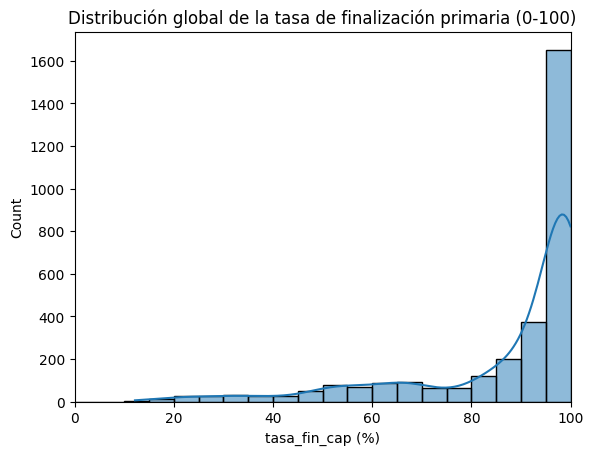

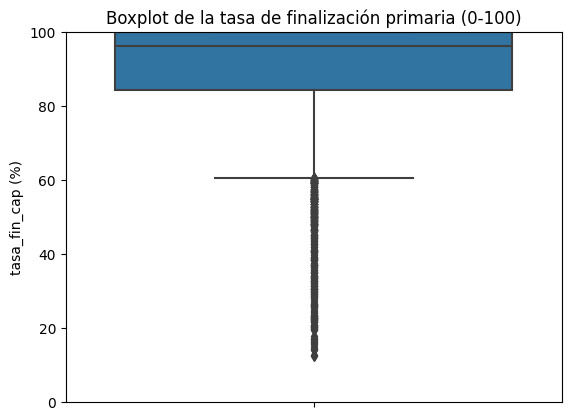

count         3004.0
mean     2011.341877
std          6.55421
min           2000.0
25%           2006.0
50%           2012.0
75%           2017.0
max           2022.0
Name: anio, dtype: Float64
(2000, 2022)


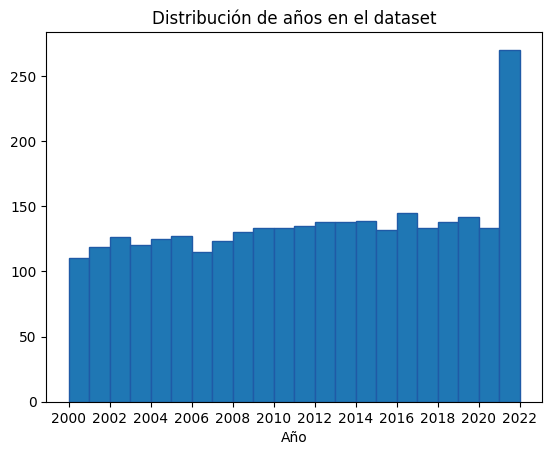

192


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

azul_main   = "#4A90E2"
azul_fuerte = "#1F5AA6"
gris_linea  = "#4D4D4D"
rojo_out    = "#D94E4E"

# Variable acotada 0-100 para visualización
data["tasa_fin_cap"] = data["tasa_fin"].clip(lower=0, upper=100)

# ============================================================
# PRUEBA ADF SOBRE LA SERIE DE TIEMPO DE tasa_fin_cap
# (mediana anual entre 2000 y 2022)
# ============================================================

# Construcción de la serie anual
serie_anual = (
    data.groupby("anio")["tasa_fin_cap"]
    .median()
    .dropna()
)

# Aplicamos la prueba ADF
resultado_adf = adfuller(serie_anual)

print("\n=== Prueba Dickey–Fuller Aumentada (ADF) ===")
print("Estadístico ADF:", resultado_adf[0])
print("p-value:", resultado_adf[1])
print("Valores críticos:")
for clave, valor in resultado_adf[4].items():
    print(f"   {clave}: {valor}")
print("============================================\n")

# ============================================================
# ANÁLISIS UNIVARIADO
# ============================================================

print(data["tasa_fin_cap"].describe())
print(data["tasa_fin_cap"].quantile([0.01, 0.25, 0.5, 0.75, 0.99]))

plt.figure()
sns.histplot(data["tasa_fin_cap"], bins=np.arange(0, 105, 5), kde=True)
plt.title("Distribución global de la tasa de finalización primaria (0-100)")
plt.xlabel("tasa_fin_cap (%)")
plt.xlim(0, 100)
plt.show()

plt.figure()
sns.boxplot(y=data["tasa_fin_cap"])
plt.title("Boxplot de la tasa de finalización primaria (0-100)")
plt.ylabel("tasa_fin_cap (%)")
plt.ylim(0, 100)
plt.show()

print(data["anio"].describe())
print((data["anio"].min(), data["anio"].max()))

plt.figure()
plt.hist(data["anio"], bins=np.arange(2000, 2023, 1), edgecolor=azul_fuerte)
plt.title("Distribución de años en el dataset")
plt.xlabel("Año")
plt.xticks(np.arange(2000, 2023, 2))
plt.show()

print(data["pais"].nunique())

El análisis univariado describe cada variable por separado para entender su comportamiento general antes de realizar comparaciones entre países o evaluar tendencias temporales. Dado que la tasa de finalización primaria puede superar el 100% según la metodología de WDI, se utiliza una versión acotada entre 0 y 100 exclusivamente para las visualizaciones, conservando los valores originales para referencia. Además, como el dataset es un panel desbalanceado, los resultados ofrecen una visión global del conjunto y no comparaciones estrictas entre países.

Antes de este análisis se aplicó la prueba Dickey–Fuller aumentada (ADF) a la serie anual de la mediana de la tasa de finalización primaria, con el fin de determinar si su evolución temporal es estacionaria. El resultado (estadístico ADF = –2.82, p‑value = 0.055) indica que no se rechaza la hipótesis nula al 5%, aunque sí al 10%, lo que sugiere una serie débilmente no estacionaria con una tendencia temporal suave.

La exploración descriptiva muestra tres patrones principales: la cobertura completa del periodo 2000–2022 con variaciones en la frecuencia anual propias de un panel desbalanceado; la concentración de la tasa de finalización primaria en valores altos con presencia de valores bajos y atípicos; y una distribución global fuertemente asimétrica, con acumulación en tasas elevadas y una cola hacia valores menores, reflejando diferencias significativas entre países.

## Analisis bivariado

Antes de iniciar el análisis bivariado, dejamos constancia de que trabajaremos con la versión acotada de la variable objetivo (tasa_fin_cap ∈ [0,100]) para asegurar visualizaciones comparables y evitar que pocos valores extremos (>100%) distorsionen escalas y patrones; la variable original (tasa_fin) se conserva y, cuando sea pertinente (p. ej., para verificar robustez), contrastaremos resultados con ella. Dado que el panel es desbalanceado (cobertura desigual por país y año), en cada contraste reportaremos el número efectivo de observaciones y el rango temporal involucrado. Asimismo, al explorar asociaciones emplearemos medidas y gráficos robustos a asimetrías y acotamientos (p. ej., correlación de Spearman además de Pearson, y bandas intercuartílicas), dejando claro que las conclusiones se interpretan condicionadas al recorte a [0,100]. Esta decisión metodológica mejora la legibilidad y la coherencia del EDA, sin renunciar a la trazabilidad de la fuente original.

In [22]:
conteo = (
    data[["pais", "anio"]]
    .drop_duplicates()
    .groupby("pais")
    .size()
    .reset_index(name="n_anios")
)

df_completo_paises = conteo[conteo["n_anios"] == 23]["pais"]

df_top = data[data["pais"].isin(df_completo_paises)].copy()

print("Número de países con datos completos:", df_top["pais"].nunique())

Número de países con datos completos: 30


In [24]:

import plotly.express as px

# Cálculo de la mediana por país (2000–2022)
map_data = df_top.groupby("pais")["tasa_fin_cap"].median().reset_index()

fig = px.choropleth(
    map_data,
    locations="pais",
    locationmode="country names",
    color="tasa_fin_cap",
    color_continuous_scale="Blues",
    range_color=(0, 100),
    title="Mediana de la tasa de finalización primaria por país (2000–2022)"
)

fig.update_layout(
    coloraxis_colorbar=dict(title="tasa_fin_cap (%)")
)

fig.show()


C:\Users\samit\AppData\Local\Temp\ipykernel_16156\449497062.py:6: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(



El mapa muestra la mediana de la tasa de finalización de la educación primaria para cada país durante el periodo 2000–2022. Los valores están representados mediante una escala de color, donde los tonos más oscuros indican tasas más altas.

En términos generales, se observa una concentración de valores elevados (cercanos al 100%) en varias regiones de Europa, América del Sur y partes de Asia Central, lo que sugiere sistemas educativos con alta cobertura y finalización primaria consistente. En contraste, algunos países presentan tonos más claros, evidenciando niveles relativamente más bajos de finalización primaria durante el periodo analizado. Esto refleja desigualdades persistentes entre regiones, influenciadas por factores estructurales, económicos y sociales.

El mapa permite visualizar de manera clara las diferencias geográficas en los niveles de finalización primaria y destaca tanto a los países con avances significativos como a aquellos que continúan rezagados.


c:\Users\samit\anaconda3\envs\dataviz_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\samit\anaconda3\envs\dataviz_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


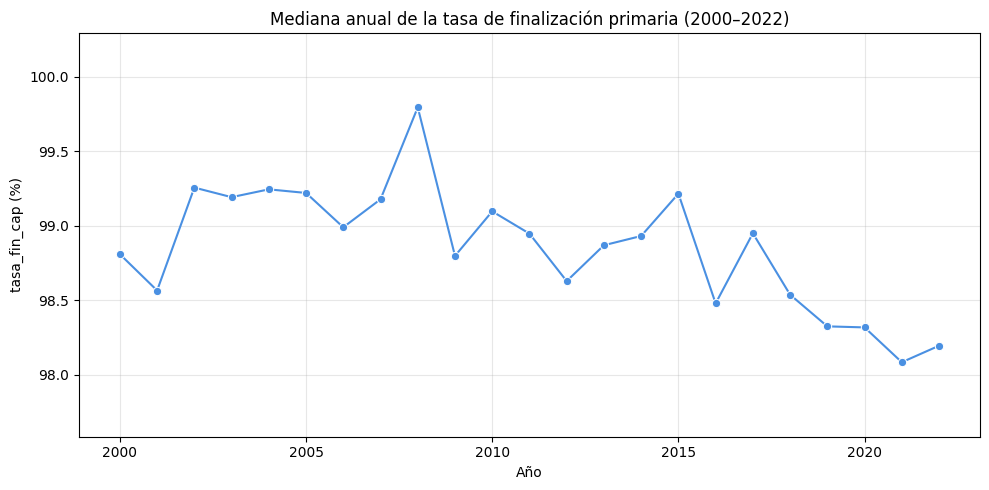

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Mediana anual
trend = df_top.groupby("anio")["tasa_fin_cap"].median().reset_index()

# Rango estrecho automático
min_y = trend["tasa_fin_cap"].min()
max_y = trend["tasa_fin_cap"].max()

# margen visual
padding = 0.5

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=trend,
    x="anio",
    y="tasa_fin_cap",
    marker="o",
    color=azul_main
)

plt.ylim(min_y - padding, max_y + padding)

plt.title("Mediana anual de la tasa de finalización primaria (2000–2022)")
plt.xlabel("Año")
plt.ylabel("tasa_fin_cap (%)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

La mediana mundial de la tasa de finalización primaria se mantiene muy alta durante todo el periodo, con valores que oscilan aproximadamente entre 98% y 100%. Aunque las variaciones son pequeñas, el zoom permite ver que existen ligeras fluctuaciones anuales y un descenso suave después de 2015. Sin embargo, el indicador sigue mostrando una estabilidad notable, lo cual refleja que, en la mayoría de países del panel, la finalización de la educación primaria ha permanecido en niveles consistentemente elevados.

In [18]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


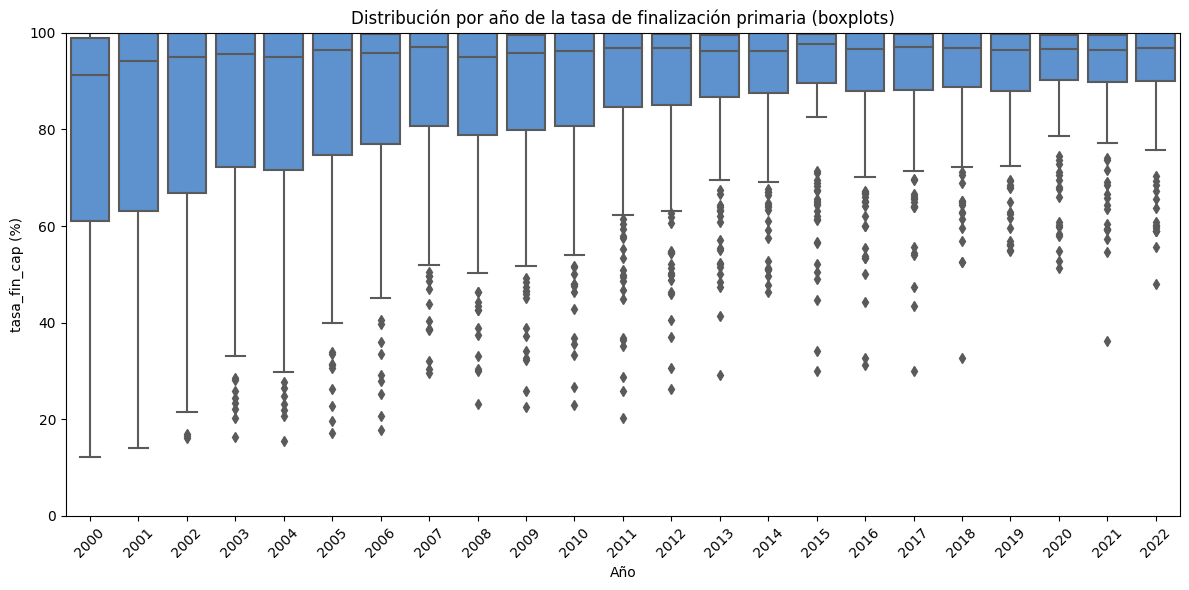

In [20]:
if "tasa_fin_cap" not in data.columns:
    data["tasa_fin_cap"] = data["tasa_fin"].clip(0, 100)

df_num = data[
    (data["tasa_fin_cap"].notna()) &
    (data["anio"].notna()) &
    (data["anio"] >= 2000) &
    (data["anio"] <= 2022)
].copy()

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_num,
    x="anio",
    y="tasa_fin_cap",
    color=azul_main
)

plt.title("Distribución por año de la tasa de finalización primaria (boxplots)")
plt.xlabel("Año")
plt.ylabel("tasa_fin_cap (%)")
plt.ylim(0, 100)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



El gráfico de cajas y bigotes muestra la distribución de la tasa de finalización primaria entre los años 2000 y 2022, permitiendo analizar cambios en tendencia, variabilidad y presencia de valores atípicos.

A lo largo del periodo observado se aprecia una mejoría sostenida en la tasa de finalización primaria:

- Al inicio de los años 2000, la mediana anual se ubicaba alrededor del 90%.
- Hacia el periodo 2015–2022, la mediana aumenta y se aproxima a valores cercanos al 97–98%.

En términos generales, los países muestran un incremento paulatino en la finalización de la educación primaria.El rango intercuartílico (IQR) se reduce con el paso de los años:

- En los primeros años (2000–2005) la variabilidad entre países es mayor.
- En los años recientes, las cajas son más estrechas, indicando mayor homogeneidad en los niveles de finalización.

Esto sugiere que los países, en promedio, han tendido a converger hacia tasas más altas y similares entre sí.

En todos los años aparecen valores atípicos por debajo del resto:

- En algunos casos, entre 15% y 40%.

Estos valores representan países con rezagos estructurales, conflictos, inestabilidad o deficiencias graves en acceso educativo. Aunque persisten, muestran un leve desplazamiento ascendente con el tiempo.


Los mínimos por año también aumentan:

- En 2000, los valores mínimos rondaban el 10–20%.
- Hacia 2020–2022, suelen encontrarse entre 30–40%.

Esto indica que incluso los países más rezagados muestran cierta mejora a lo largo del tiempo.

Debido al truncamiento entre 0 y 100:

- Los bigotes superiores alcanzan el 100% cada año.
- Varios países registran tasas máximas, consistentes con sistemas educativos con cobertura casi universal.

El análisis revela una mejora sistemática en la finalización primaria a nivel global, junto con una mayor convergencia entre países. Persiste un grupo reducido de países con tasas bajas, aunque también mejoran. Paralelamente, un número creciente de países alcanza niveles cercanos o iguales al 100%.
